Misma idea que en `Comparacion_Boyas_UPCT_IMIDA_raw.ipynb` pero usando ya los dataframes procesados y con las fechas en las que hay también imagen de satélite.

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import re
pd.options.mode.chained_assignment = None

In [2]:
# Cargamos los csv de los tifs
path = "saved_files/dataset/"
dfs = {}
for archivo in os.listdir(path):
    if archivo.endswith(".csv") and not archivo.endswith("_features.csv") and archivo.startswith("c2x-nets") :
        nombre_sin_extension = os.path.splitext(archivo)[0]  # sin .csv
        ruta_completa = os.path.join(path, archivo)
        dfs[nombre_sin_extension] = pd.read_csv(ruta_completa)

In [3]:
dates = set(dfs["c2x-nets_1x1_imida_depth_eq_0"]["Date"]).intersection(set(dfs["c2x-nets_1x1_upct_depth_eq_0"]["Date"]))

In [4]:
for nombre_df, df in dfs.items():
        dfs[nombre_df] = df.loc[df["Date"].isin(dates),:]

In [5]:
from collections import defaultdict
import re

comparables = defaultdict(lambda: {'upct': None, 'imida': None})

for name, df in dfs.items():
    match = re.match(r'c2x-nets_(\d+x\d+)_(upct|imida)_depth_(.*)', name)
    if match:
        ventana, tipo, profundidad = match.groups()
        comparables[(ventana, profundidad)][tipo] = df


In [6]:
ventana = "3x3"
subconjunto = [
    (ventana, "lt_1"),
    (ventana, "eq_0"),
    (ventana, "eq_1"),
    (ventana, "lt_2"),
    (ventana, "gt_1"),
]

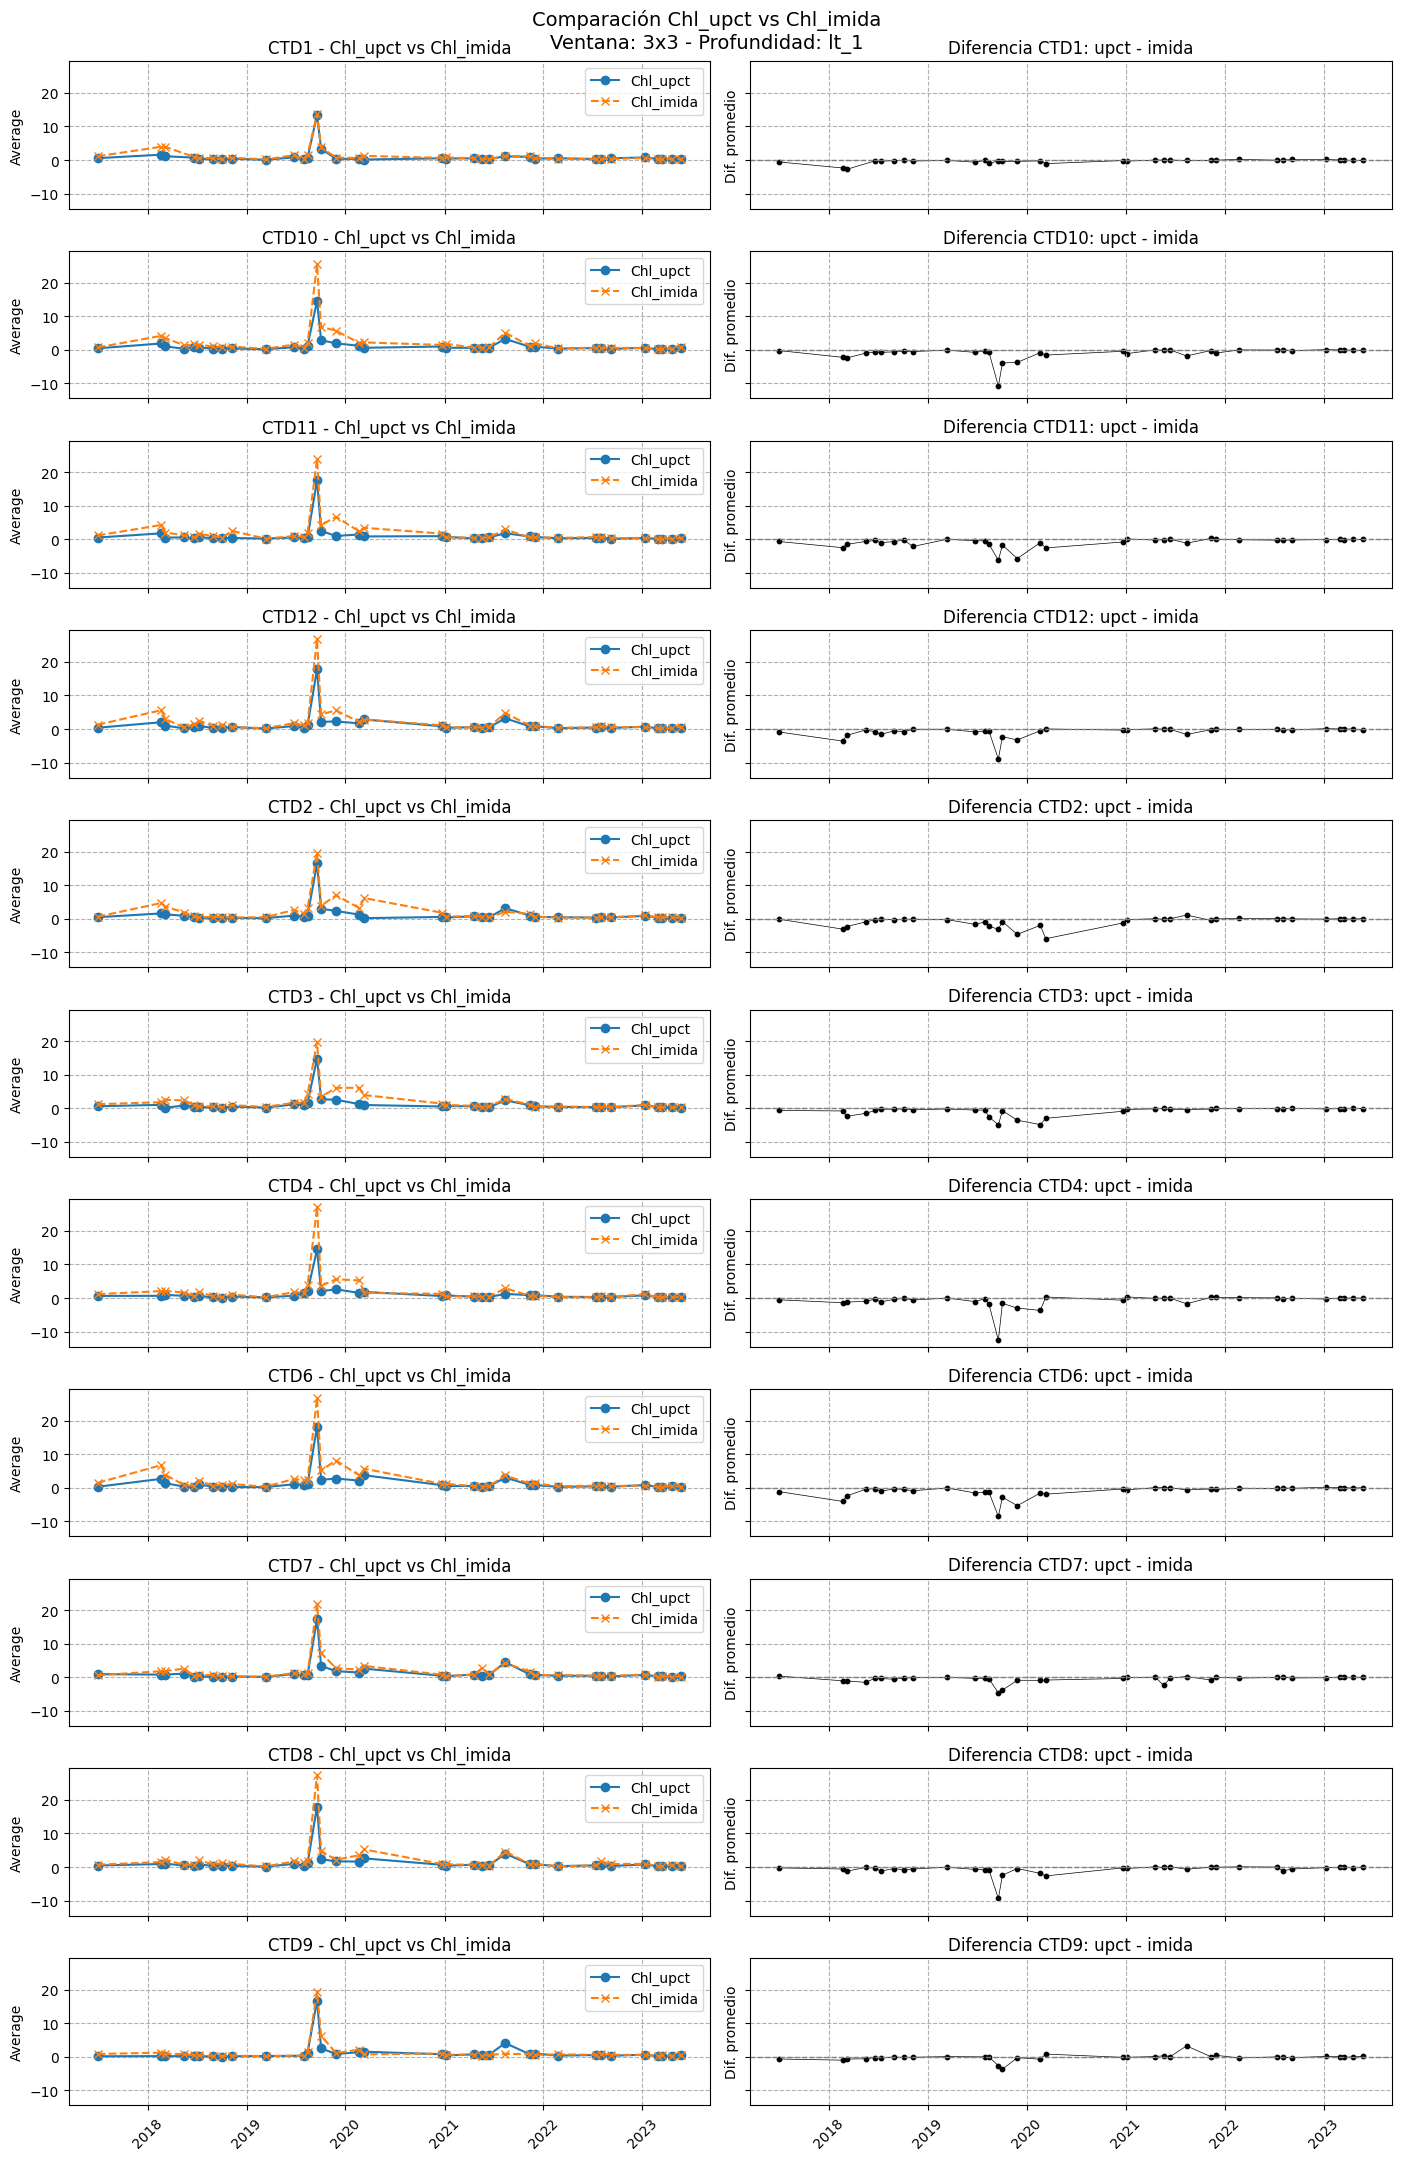

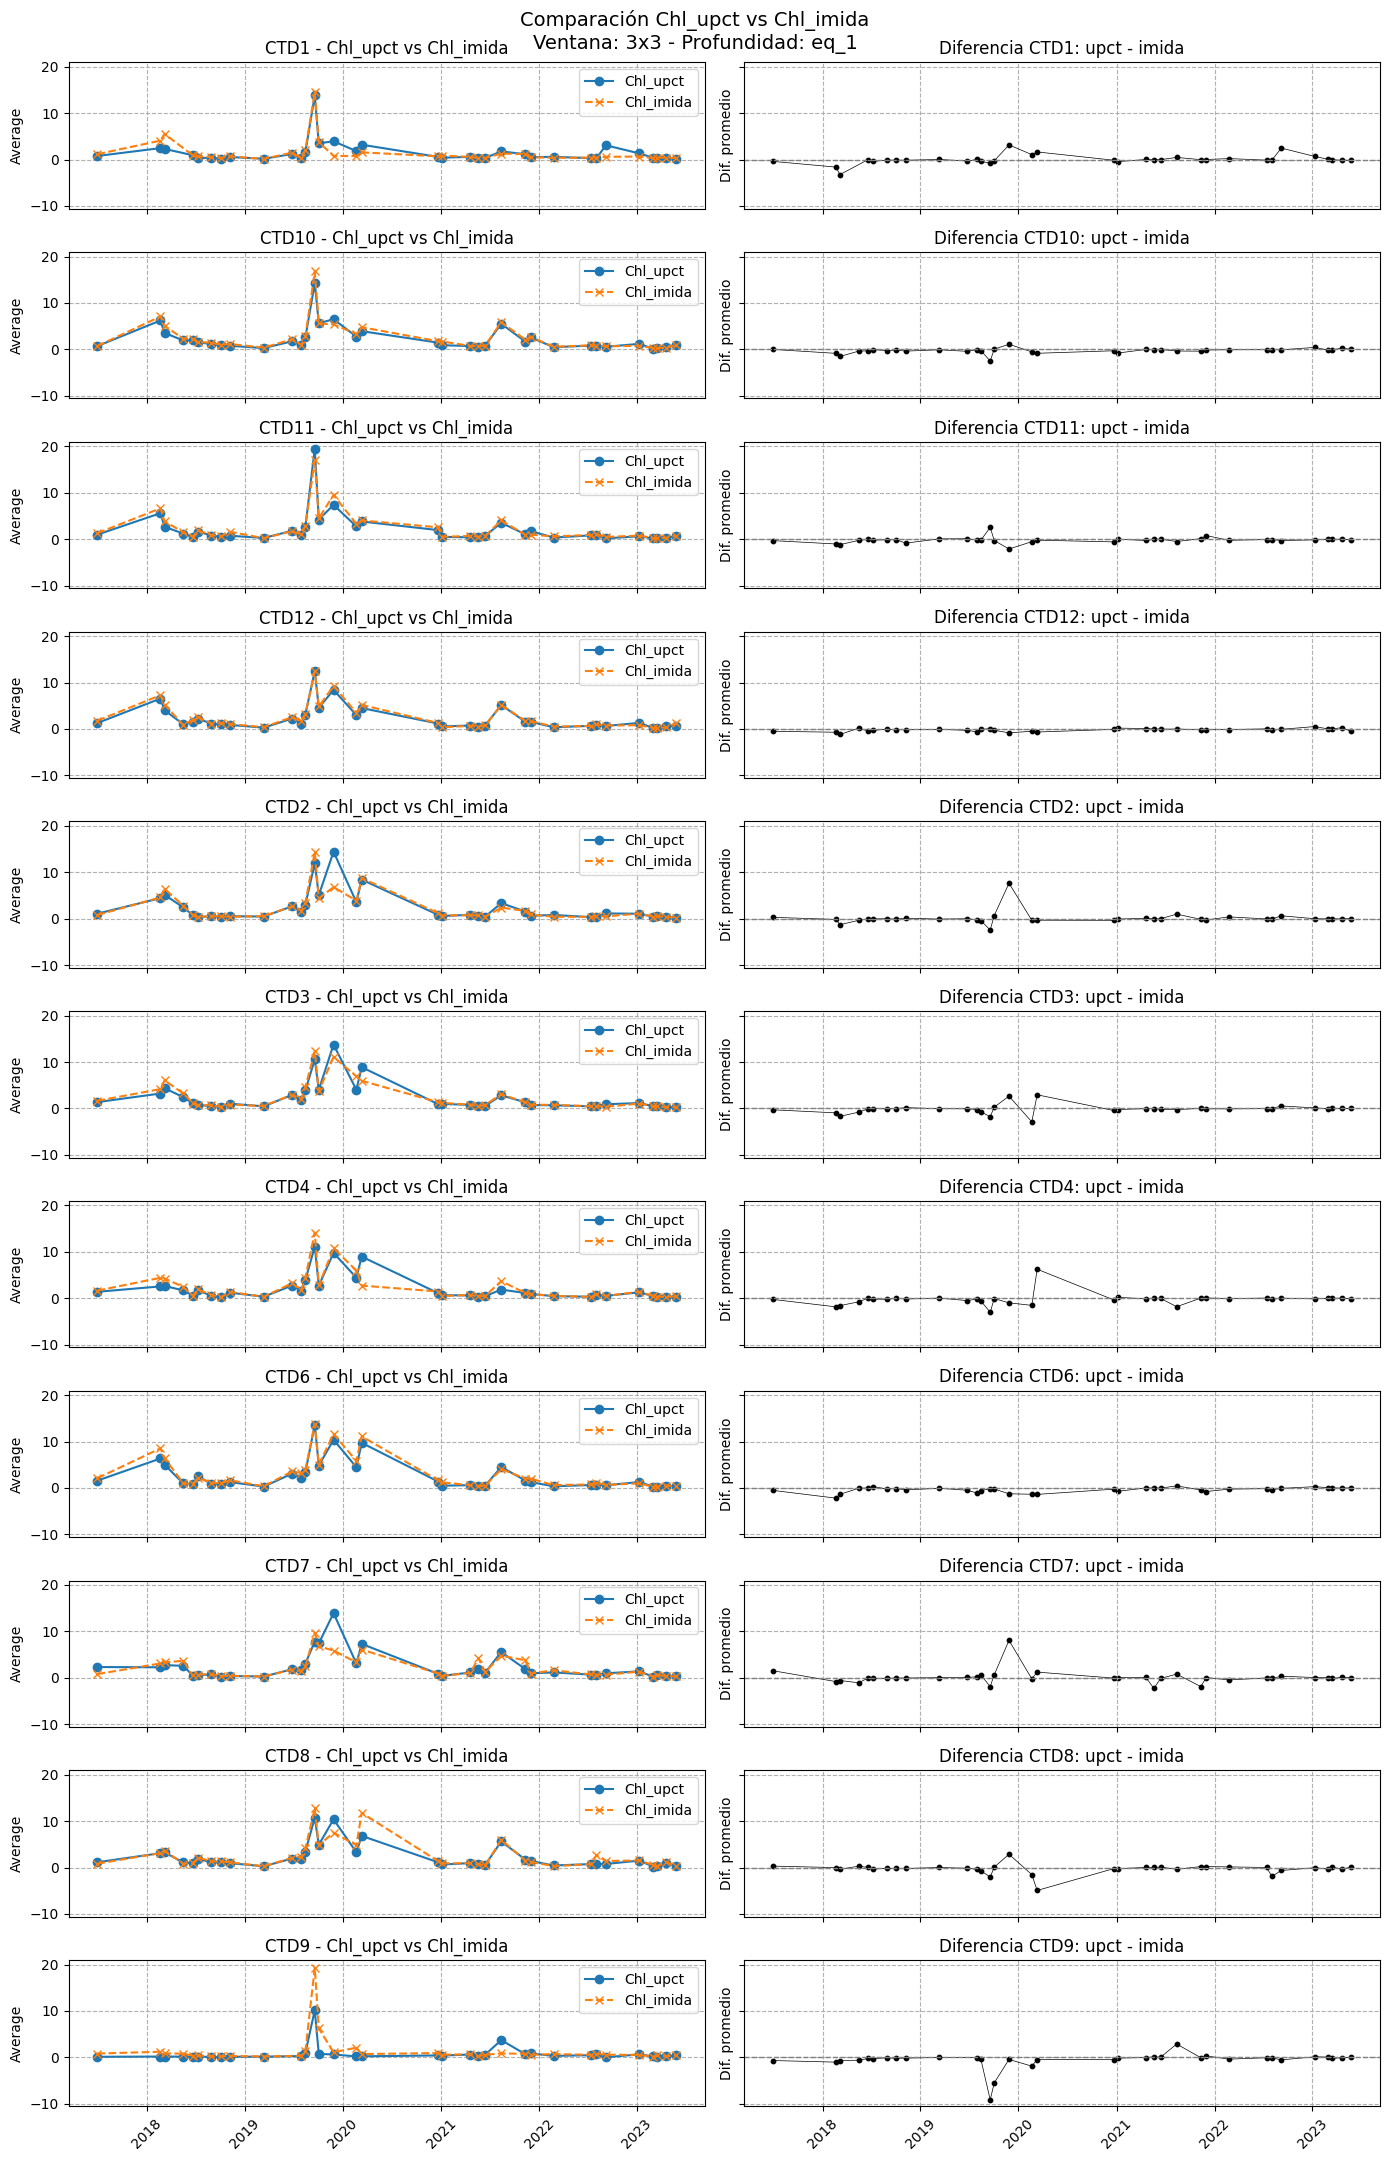

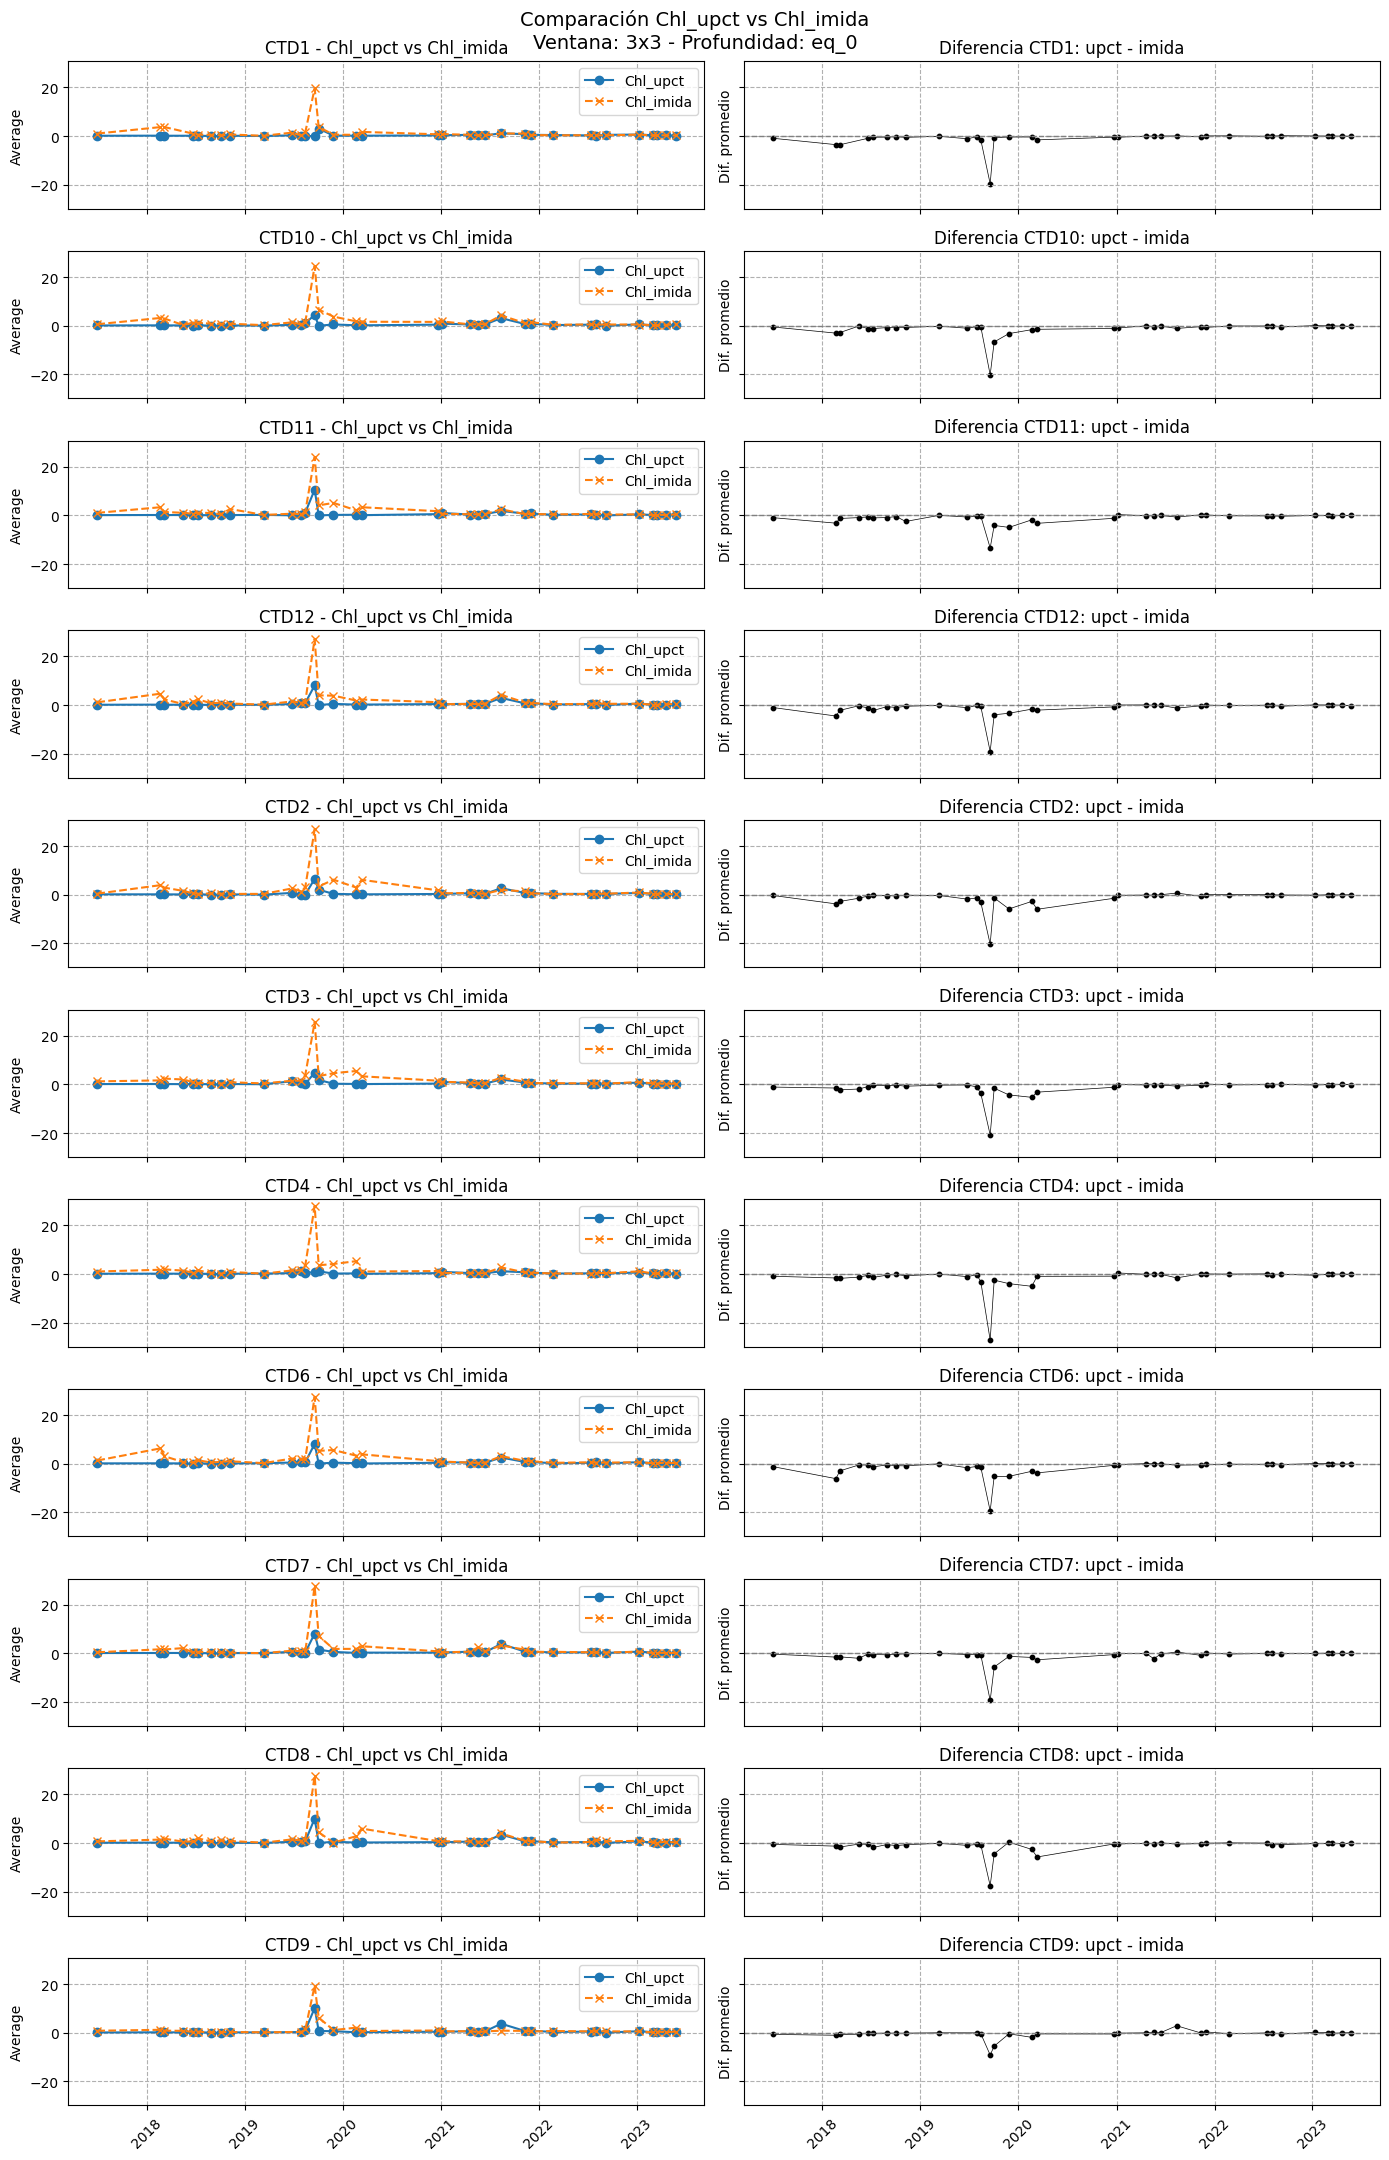

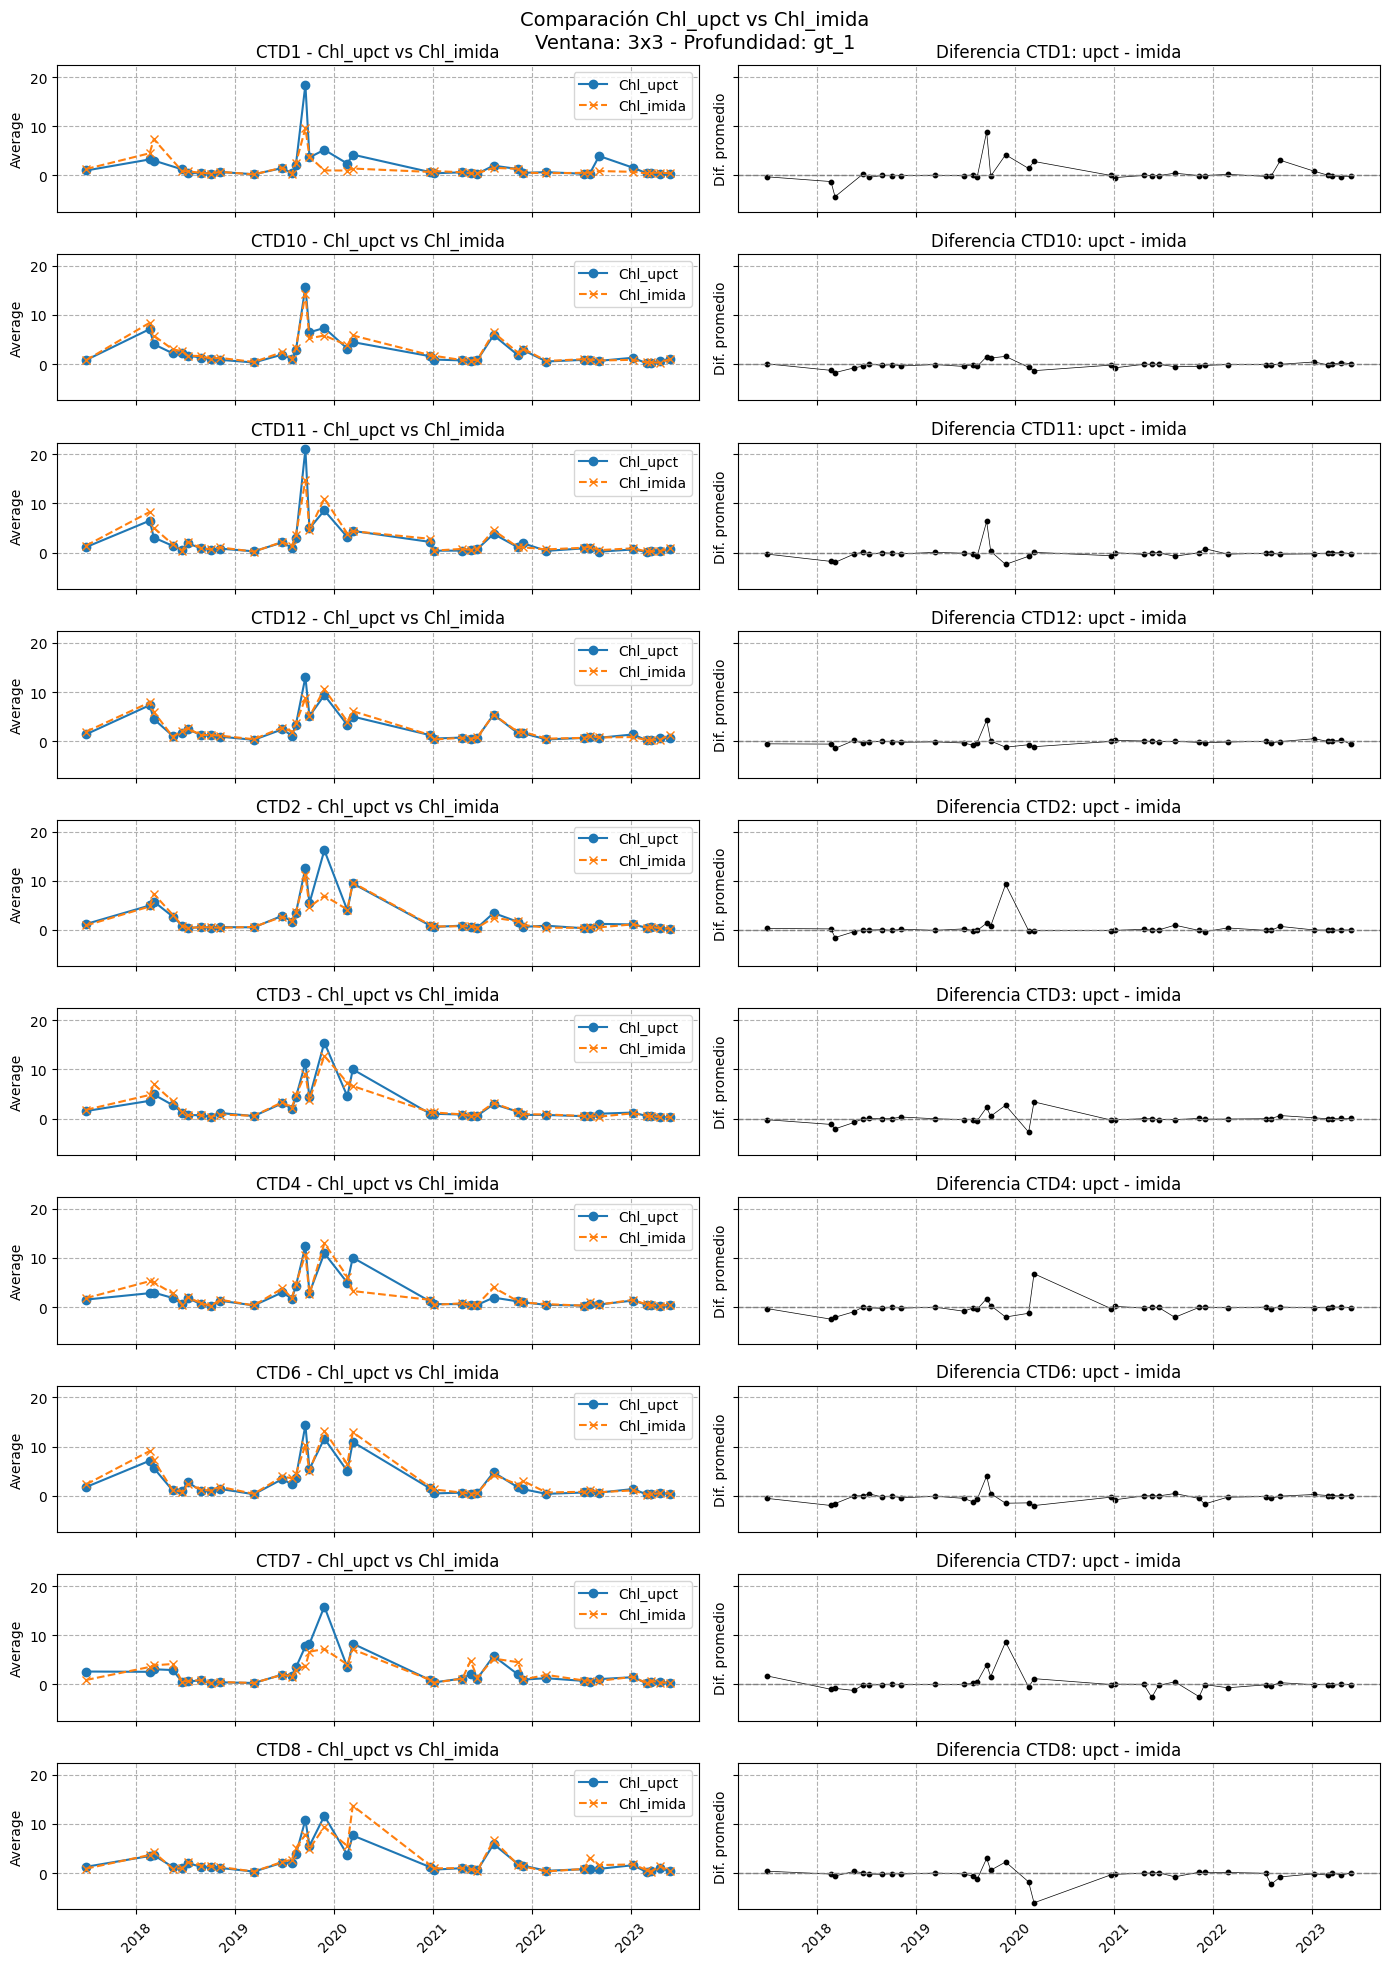

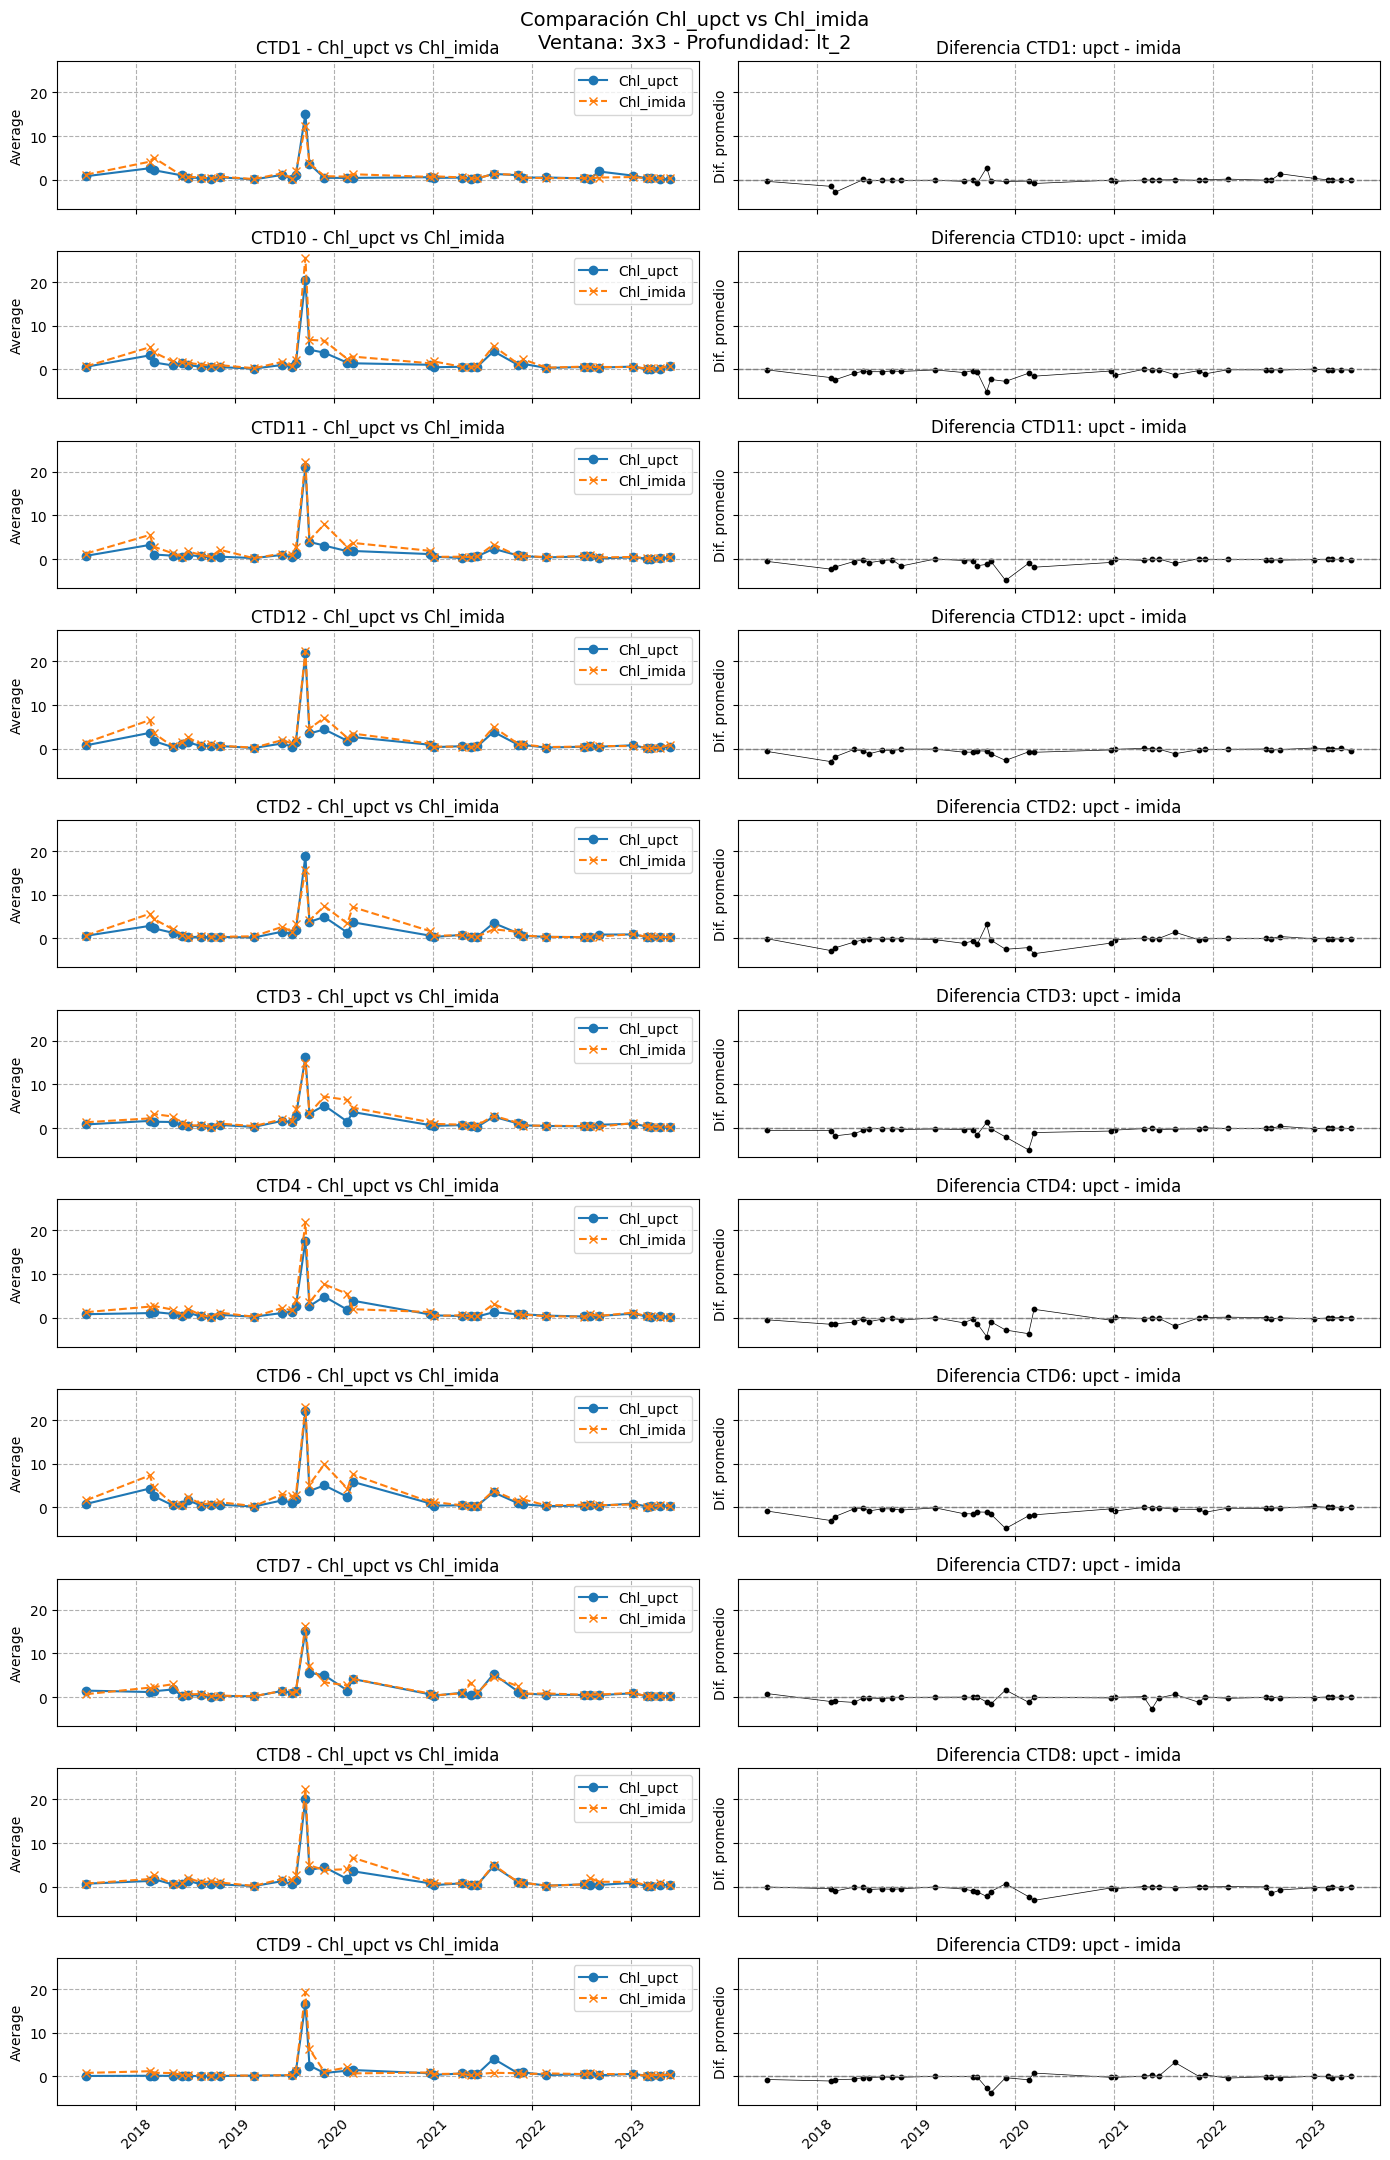

In [7]:
for (ventana, profundidad), tipos in comparables.items():

    if (ventana, profundidad) not in subconjunto:
        continue 
    df_upct = tipos['upct']
    df_imida = tipos['imida']

    if df_upct is not None and df_imida is not None:
        # Unificar fechas y boyas
        fechas_comunes = set(df_upct['Date']).intersection(df_imida['Date'])
        df_upct_filtrado = df_upct[df_upct['Date'].isin(fechas_comunes)]
        df_imida_filtrado = df_imida[df_imida['Date'].isin(fechas_comunes)]

        df_upct['Date'] = pd.to_datetime(df_upct['Date'])
        df_imida['Date'] = pd.to_datetime(df_imida['Date'])


        # Merge por Date y Buoy
        merged = pd.merge(
            df_upct_filtrado[['Date', 'Buoy', 'Chl']],
            df_imida_filtrado[['Date', 'Buoy', 'Chl']],
            on=['Date', 'Buoy'],
            suffixes=('_upct', '_imida')
        )

        merged = merged.sort_values(['Buoy', 'Date'])

        # Calcular diferencia
        merged['Chl_diff'] = merged['Chl_upct'] - merged['Chl_imida']

        buoys = merged['Buoy'].unique() #["CTD1", "CTD2", "CTD3"]#

        fig, axes = plt.subplots(len(buoys), 2, figsize=(14, 2 * len(buoys)), sharex='col', sharey=True)
        fig.suptitle(f"Comparación Chl_upct vs Chl_imida\nVentana: {ventana} - Profundidad: {profundidad}", fontsize=14)
        if len(buoys) == 1:
            axes = [axes]  # hacer iterable si solo hay una boya

        for i, buoy in enumerate(buoys):
            df_buoy = merged[merged['Buoy'] == buoy]
            df_buoy['Date'] = pd.to_datetime(df_buoy['Date'])
            # --- Panel izquierdo: las dos series ---
            axes[i][0].plot(df_buoy['Date'], df_buoy['Chl_upct'], label='Chl_upct', marker='o', linestyle='-')
            axes[i][0].plot(df_buoy['Date'], df_buoy['Chl_imida'], label='Chl_imida', marker='x', linestyle='--')
            axes[i][0].set_title(f"{buoy} - Chl_upct vs Chl_imida")
            axes[i][0].set_ylabel("Average")
            axes[i][0].grid(True, linestyle = '--')
            axes[i][0].legend()

            # --- Panel derecho: diferencia ---
            axes[i][1].scatter(df_buoy['Date'], df_buoy['Chl_diff'], color='black', s=10)
            axes[i][1].plot(df_buoy['Date'], df_buoy['Chl_diff'], color='black', linewidth=0.5)
            axes[i][1].axhline(0, color='gray', linestyle='--', linewidth=1)
            axes[i][1].set_title(f"Diferencia {buoy}: upct - imida")
            axes[i][1].set_ylabel("Dif. promedio")
            axes[i][1].grid(True, linestyle = '--')

            # Rotación de fechas para ambos paneles
            axes[i][0].tick_params(axis='x', rotation=45)
            axes[i][1].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

In [14]:
# Diccionario para guardar estadísticas
estadisticas_diferencias = {}

ventanas = ["3x3"]
for ventana in ventanas:
    subconjunto = [
        (ventana, "lt_1"),
        (ventana, "eq_0"),
        (ventana, "eq_1"),
        (ventana, "lt_2"),
        (ventana, "gt_1"),
    ]


    for (ventana, profundidad), tipos in comparables.items():

        if (ventana, profundidad) not in subconjunto:
            continue 
        df_upct = tipos['upct']
        df_imida = tipos['imida']

        if df_upct is not None and df_imida is not None:
            # Unificar fechas y boyas
            fechas_comunes = set(df_upct['Date']).intersection(df_imida['Date'])
            df_upct_filtrado = df_upct[df_upct['Date'].isin(fechas_comunes)]
            df_imida_filtrado = df_imida[df_imida['Date'].isin(fechas_comunes)]

            df_upct['Date'] = pd.to_datetime(df_upct['Date'])
            df_imida['Date'] = pd.to_datetime(df_imida['Date'])

            # Merge por Date y Buoy
            merged = pd.merge(
                df_upct_filtrado[['Date', 'Buoy', 'Chl']],
                df_imida_filtrado[['Date', 'Buoy', 'Chl']],
                on=['Date', 'Buoy'],
                suffixes=('_upct', '_imida')
            )

            merged = merged.sort_values(['Buoy', 'Date'])

            # Calcular diferencia
            merged['Chl_diff'] = merged['Chl_upct'] - merged['Chl_imida']

            # Calcular estadísticas
            media = merged['Chl_diff'].mean()
            std = merged['Chl_diff'].std()

            # Guardar en el diccionario
            estadisticas_diferencias[(ventana, profundidad)] = {
                'media': media,
                'std': std,
                'n': len(merged)  # opcional: cantidad de datos usados
            }


In [16]:
for clave, stats in estadisticas_diferencias.items():
    print(f"Ventana {clave[0]}, Profundidad {clave[1]}: Media = {stats['media']:.3f}, STD = {stats['std']:.3f}")


Ventana 3x3, Profundidad lt_1: Media = -0.795, STD = 1.544
Ventana 3x3, Profundidad eq_1: Media = -0.191, STD = 1.142
Ventana 3x3, Profundidad eq_0: Media = -1.340, STD = 3.338
Ventana 3x3, Profundidad gt_1: Media = -0.025, STD = 1.376
Ventana 3x3, Profundidad lt_2: Media = -0.493, STD = 0.964
